<a href="https://colab.research.google.com/github/Srimant1323/Water-Quality-Data-Analysis/blob/main/H20_Potability_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Water Potability Data Analysis

This is a self-practice data analysis project developed to explore water quality parameters and understand how different features relate to water potability.

The dataset was obtained from a public repository and analyzed using Python in Google Colab.

Steps performed in this project:
• Data loading
• Data cleaning
• Handling missing values
• Exploratory Data Analysis (EDA)
• Correlation analysis using heatmap
• Data visualization using multiple graphs

This project was created as part of my self-learning and practice in data analysis and visualization.

Tools Used:
Python, Pandas, Matplotlib, Seaborn, Google Colab

In [1]:
from google.colab import files
uploaded = files.upload()

Saving water_potability.csv to water_potability.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("water_potability.csv")

df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
df.shape

(3276, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [6]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [7]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


### Handling Missing Values
Missing values in pH, Sulfate, and Trihalomethanes were replaced with the mean of the respective columns to maintain dataset consistency.


In [9]:
df['ph'] = df['ph'].fillna(df['ph'].mean())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].mean())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean())

In [10]:
df.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


HISTOGRAM


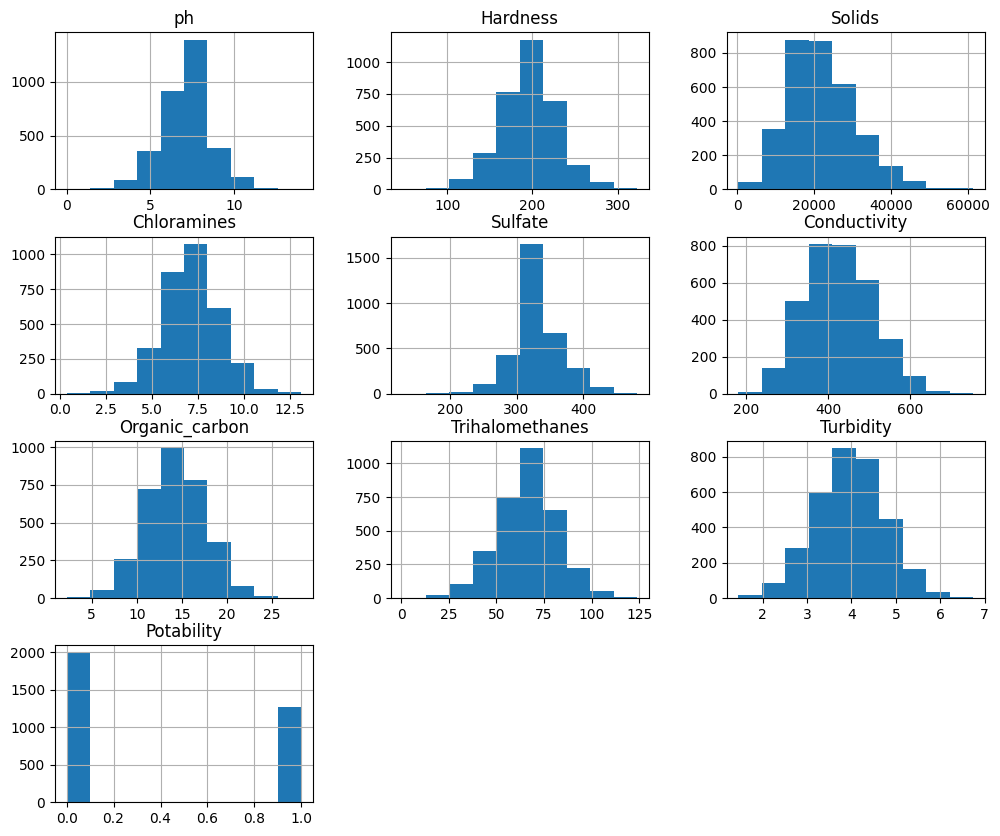

In [11]:
df.hist(figsize=(12,10))
plt.show()

CORRELATION HEATMAP


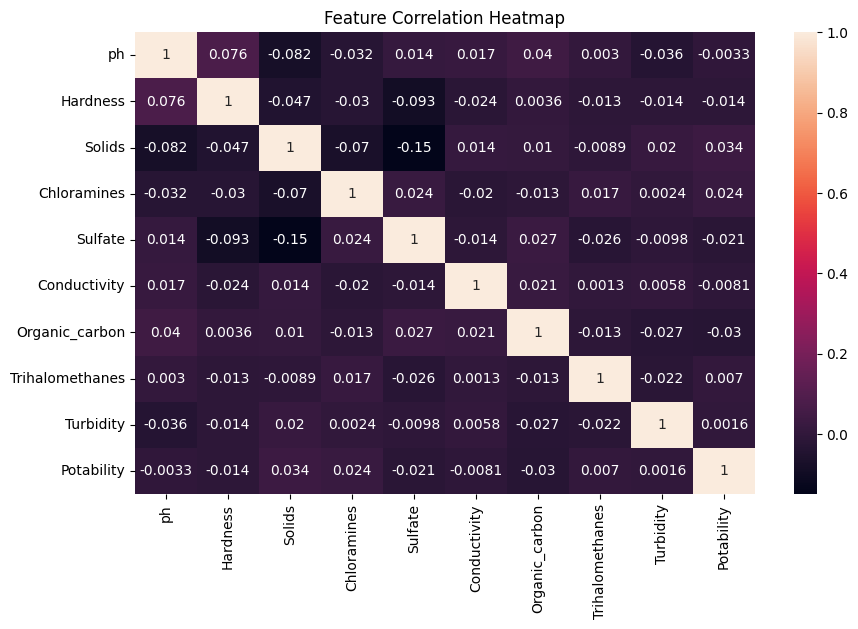

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

### Heatmap Interpretation

The correlation heatmap shows the relationship between different water quality parameters.

Most correlation values are close to zero, indicating weak relationships between variables.
This suggests that no single parameter strongly determines water potability.

Some weak correlations are observed, such as between Solids and Sulfate (-0.15), but overall the dataset shows low linear dependency between features.

This means that water quality assessment requires considering multiple parameters together rather than relying on a single factor.

POTABILITY COUNT PLOT

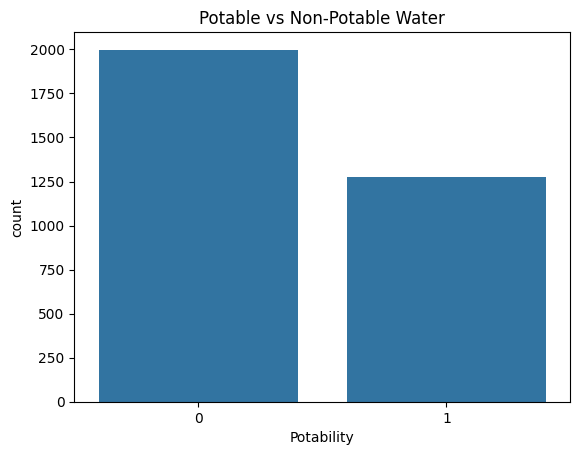

In [13]:
sns.countplot(x='Potability', data=df)
plt.title("Potable vs Non-Potable Water")
plt.show()

pH DISTRIBUTION

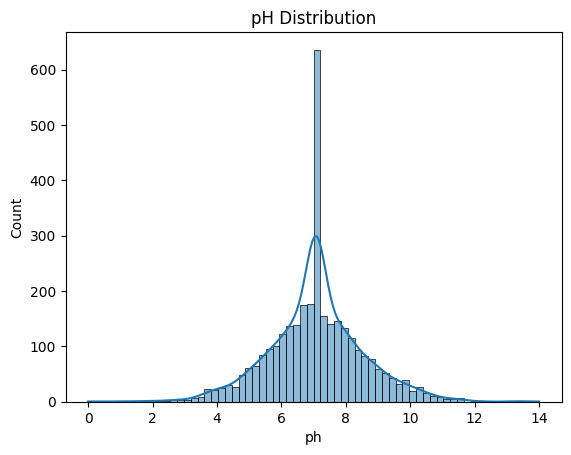

In [14]:
sns.histplot(df['ph'], kde=True)
plt.title("pH Distribution")
plt.show()

In [15]:
df.to_csv("cleaned_water_data.csv", index=False)